In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.analysis.calculate_metastability_optimize_K import (find_optimal_K,
                                                             plot_K_optimization,
                                                             plot_arr_K_optimization
)

%load_ext autoreload
%autoreload 2 

from vizman import viz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

In [8]:
# Newly constructed connectivity matrix from distance matrix 
# name_data = "distance_matrix_50"
name_data = "00_connectomes_orig" # 
# name_data = "01_consensus_bin_density_10_percent_50"


# ################################### EITHER: ###################################

# if name_data.startswith("distance_matrix"):
#     # Load distance matrices and convert to connectomes
#     distance_matrix_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/{name_data}.npy"
#     distance_matrices = np.load(distance_matrix_path)

#     connectomes = []
#     for d in distance_matrices:
#         A = np.exp(-d / d.max())
#         np.fill_diagonal(A, 0)  # No self-connections
#         A = (A + A.T) / 2  # Make symmetric
#         A = (A - A.min()) / (A.max() - A.min())
#         np.fill_diagonal(A, 0)  # No self-connections
#         connectomes.append(A)

#     connectomes = np.array(connectomes)
#     name_data = name_data + "_not_thresholded"


################################### OR: ###################################


if name_data.startswith("01_consensus") or name_data.startswith("00_connectomes"):
    # Load preprocessed connectomes
    data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{name_data}.npy"
    connectomes = np.load(data_path)


In [4]:
save_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/basic_analyses/{name_data}") # {name_data}_finer_window")
save_path.mkdir(parents=True, exist_ok=True)

ids_to_evaluate = range(225) #  [0, 103, 169, 188, 206]

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/basic_analyses/01_consensus_bin_density_10_percent_50/degree_hists


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_9787/3402424207.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(viz.cm_to_inch((8,6))))


[np.float64(3.7644723618090454), np.float64(2.4443718592964823), np.float64(4.00251256281407), np.float64(2.838391959798995), np.float64(3.236030150753769), np.float64(2.4087939698492464), np.float64(3.427889447236181), np.float64(3.4841206030150755), np.float64(4.554371859296483), np.float64(2.3684924623115577), np.float64(5.428643216080402), np.float64(4.426733668341709), np.float64(2.6175879396984927), np.float64(3.1280904522613064), np.float64(2.904673366834171), np.float64(2.6608542713567838), np.float64(3.1829145728643216), np.float64(6.505226130653266), np.float64(1.3580904522613064), np.float64(7.828040201005025), np.float64(3.655527638190955), np.float64(13.410251256281407), np.float64(4.332713567839196), np.float64(4.282311557788945), np.float64(1.9559798994974875), np.float64(2.8083417085427134), np.float64(3.8766331658291455), np.float64(3.348040201005025), np.float64(3.6418090452261307), np.float64(3.408291457286432), np.float64(4.9720100502512565), np.float64(2.3671356783

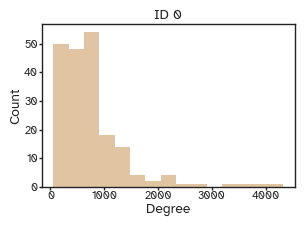

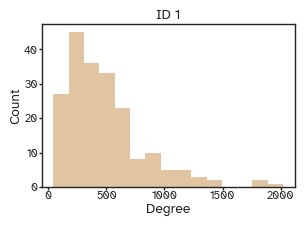

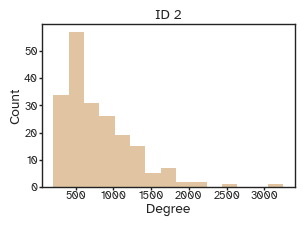

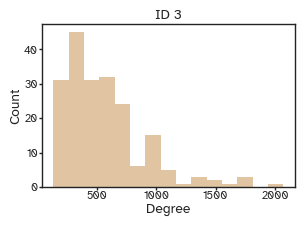

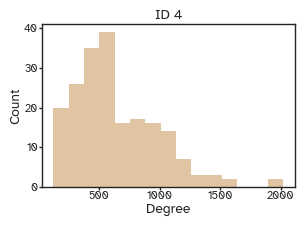

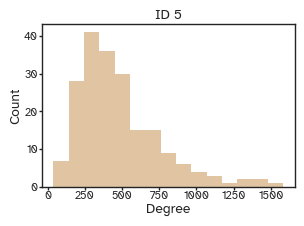

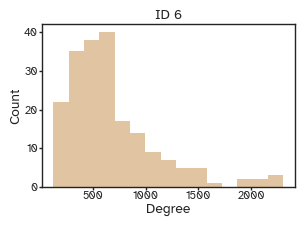

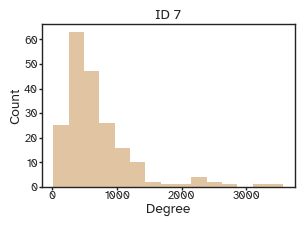

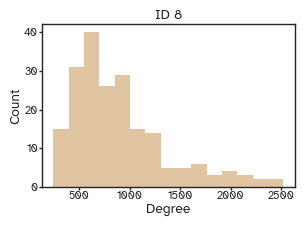

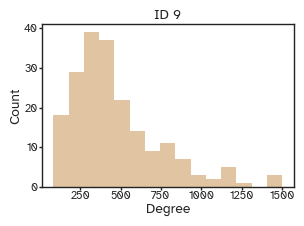

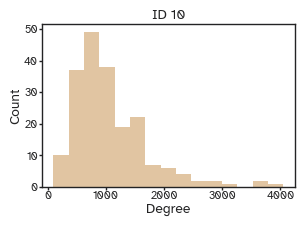

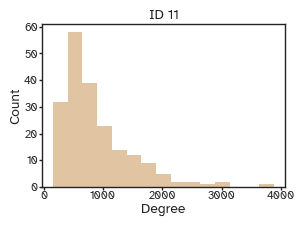

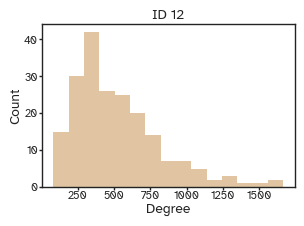

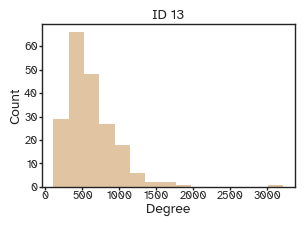

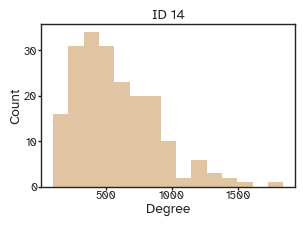

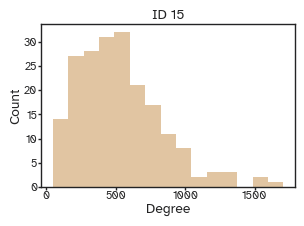

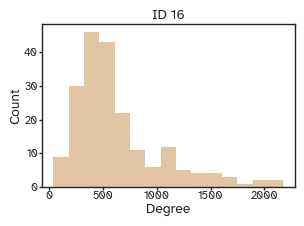

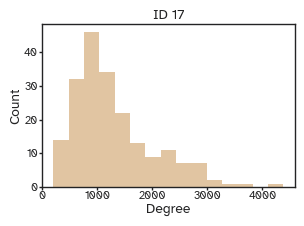

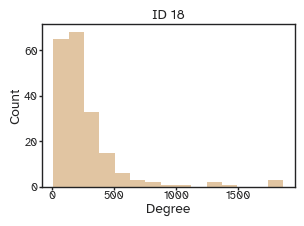

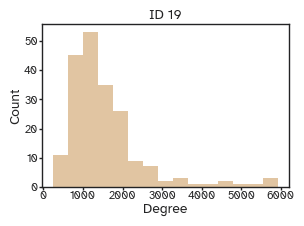

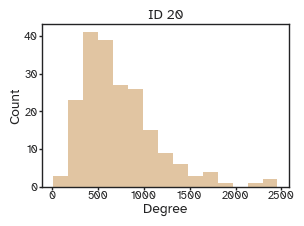

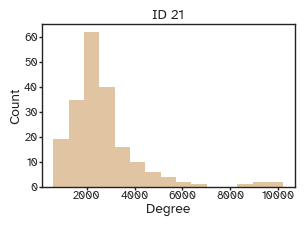

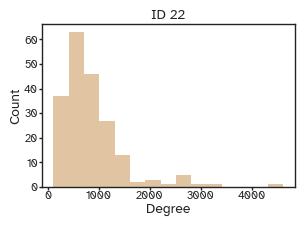

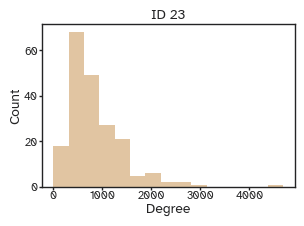

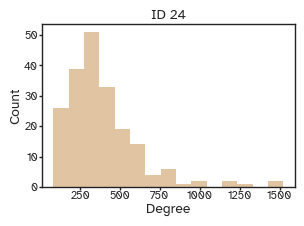

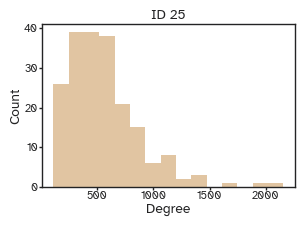

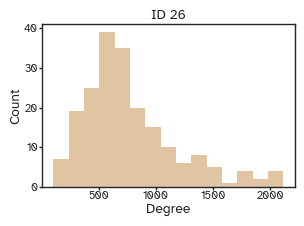

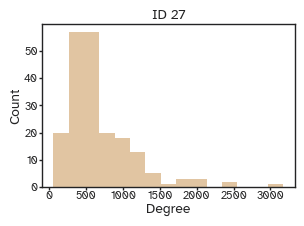

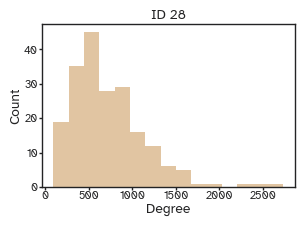

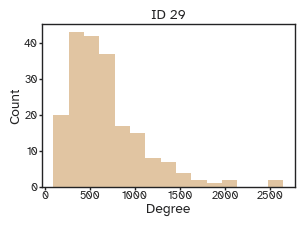

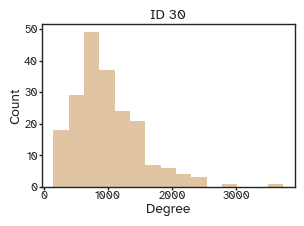

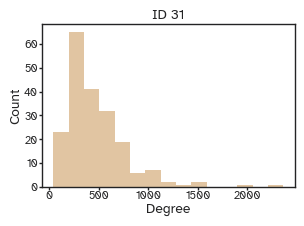

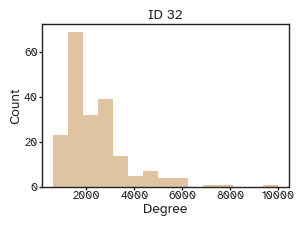

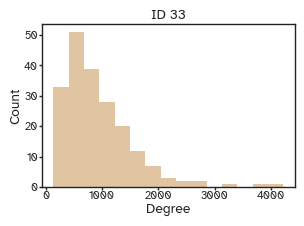

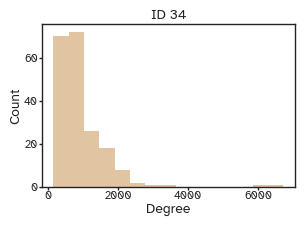

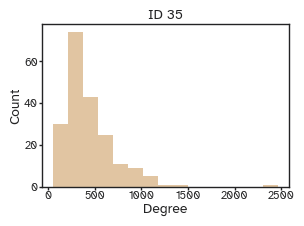

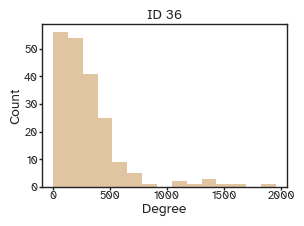

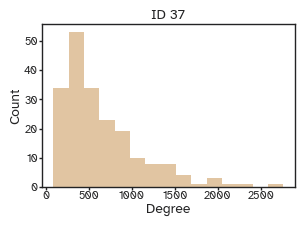

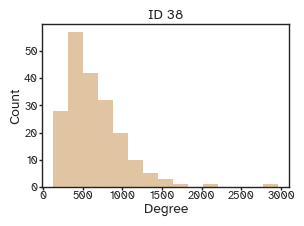

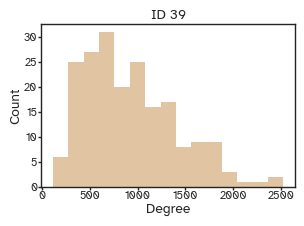

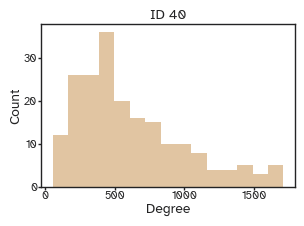

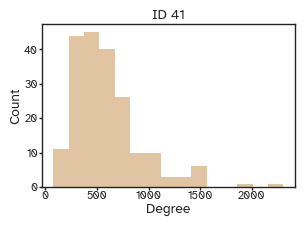

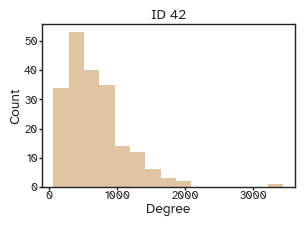

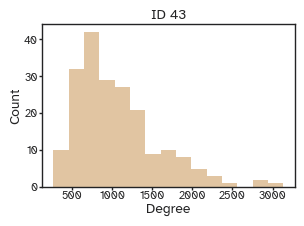

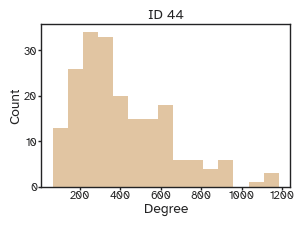

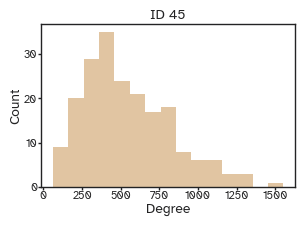

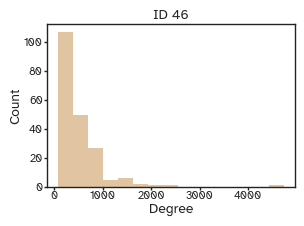

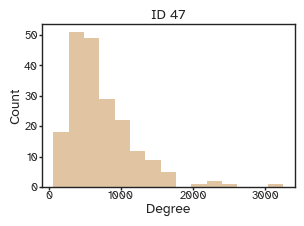

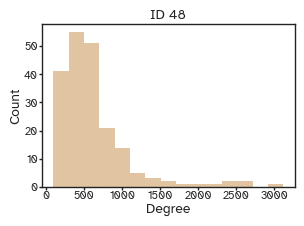

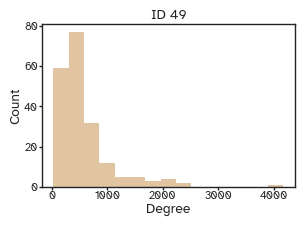

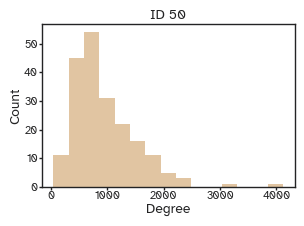

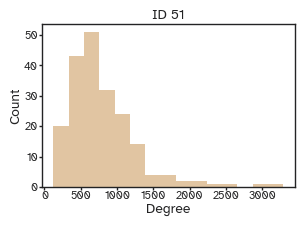

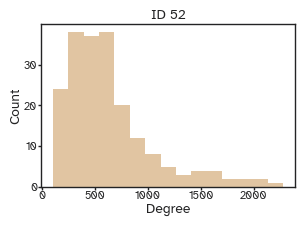

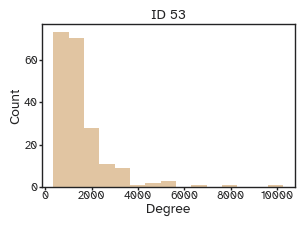

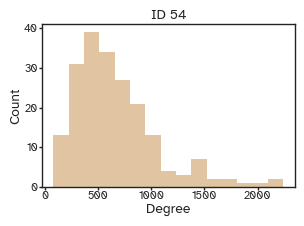

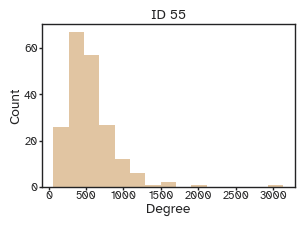

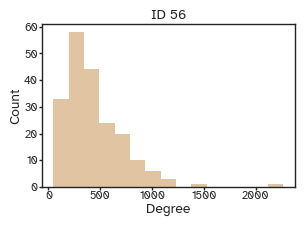

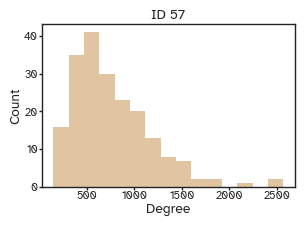

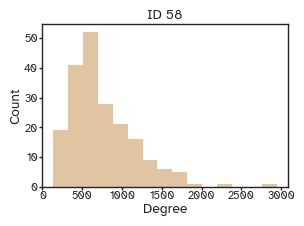

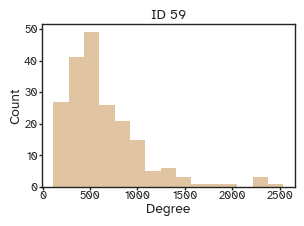

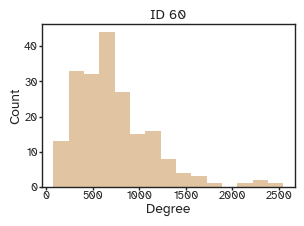

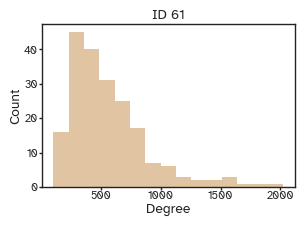

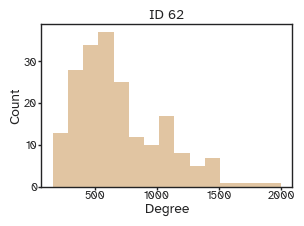

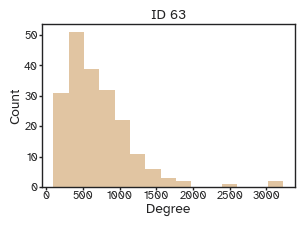

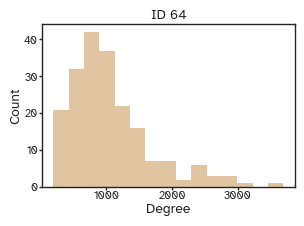

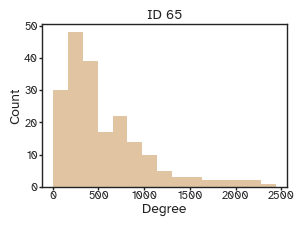

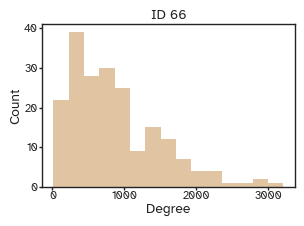

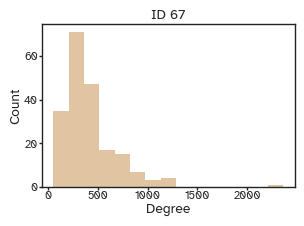

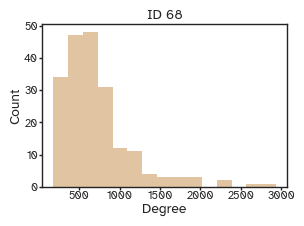

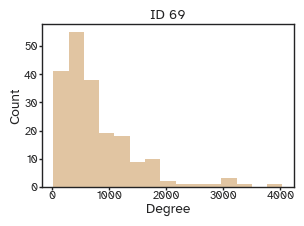

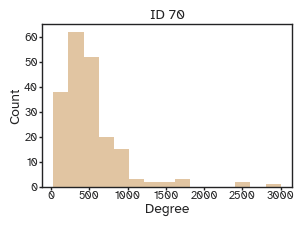

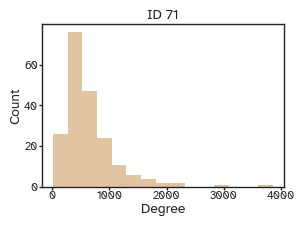

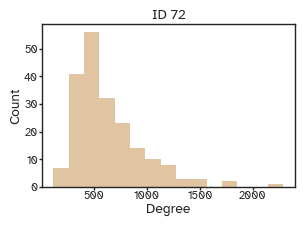

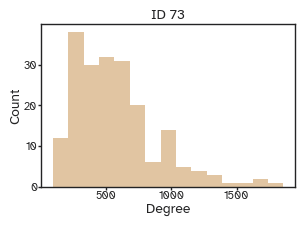

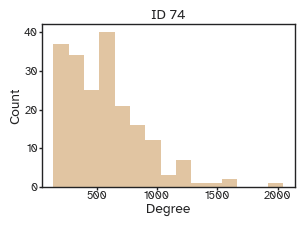

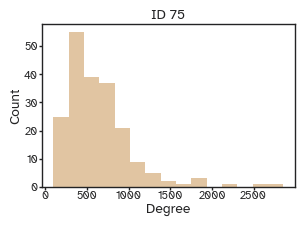

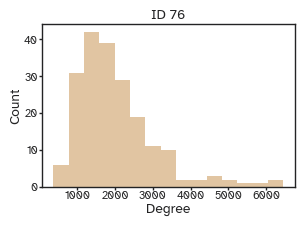

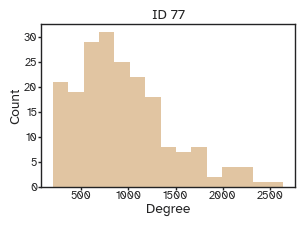

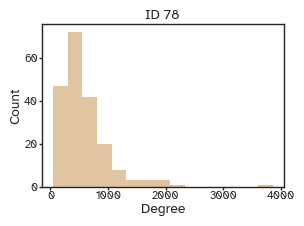

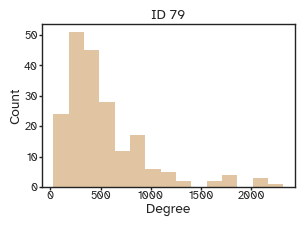

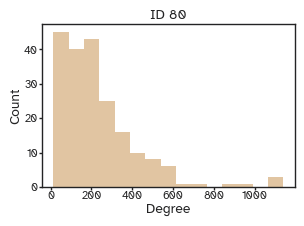

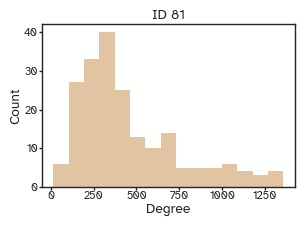

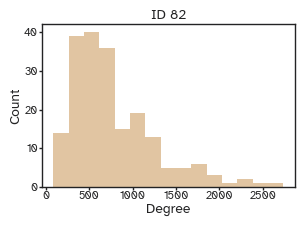

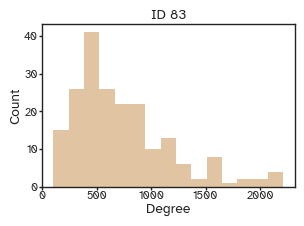

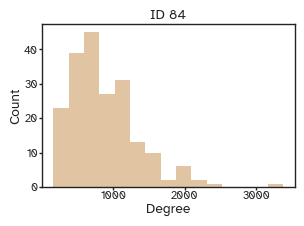

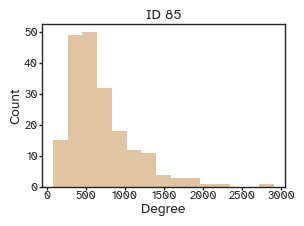

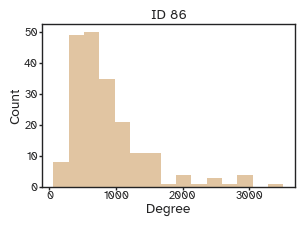

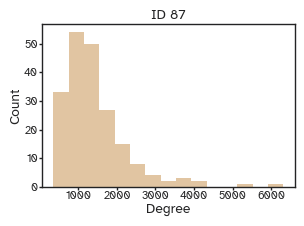

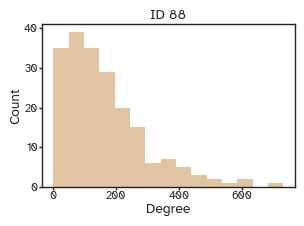

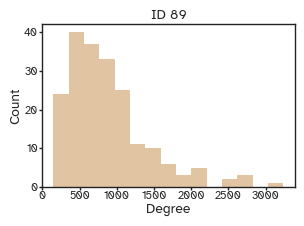

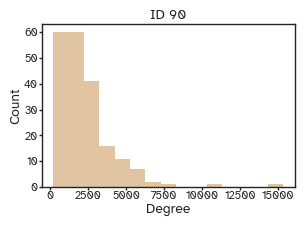

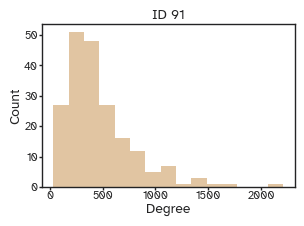

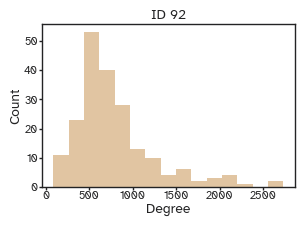

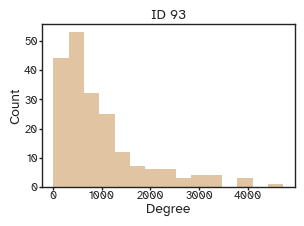

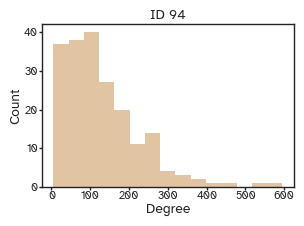

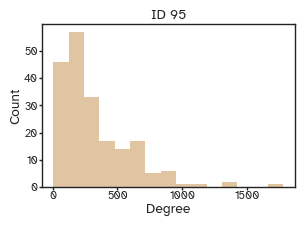

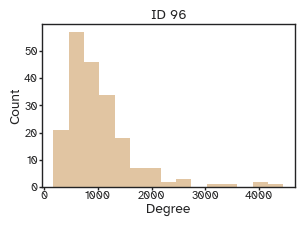

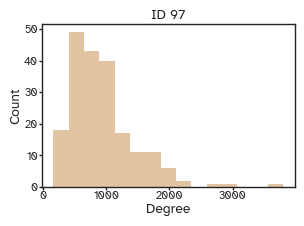

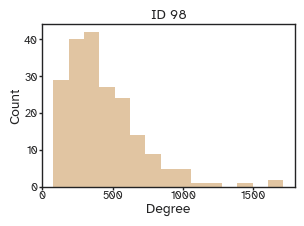

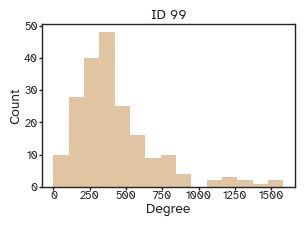

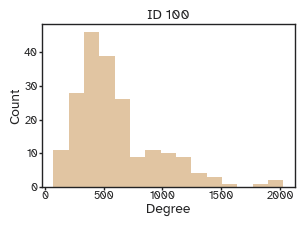

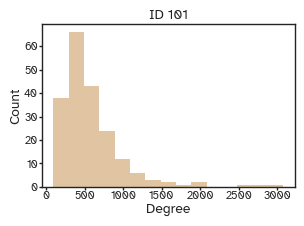

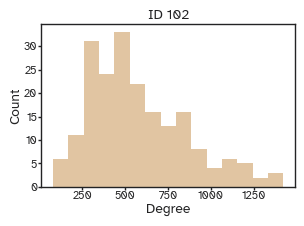

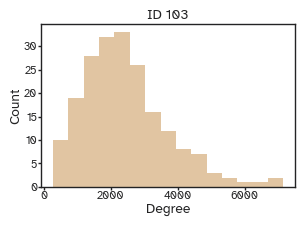

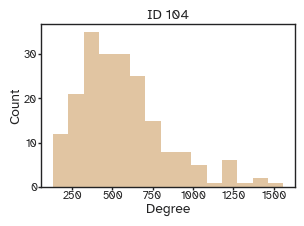

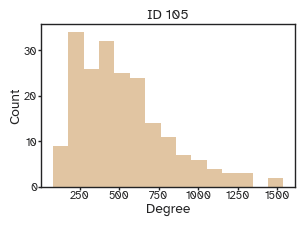

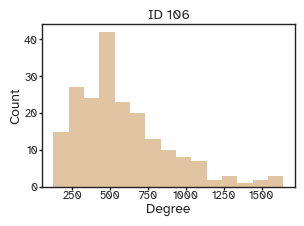

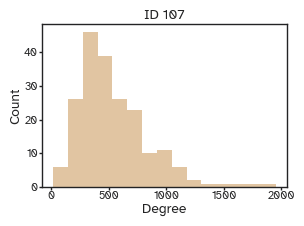

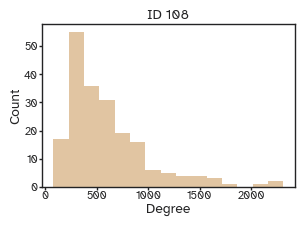

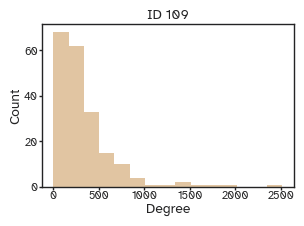

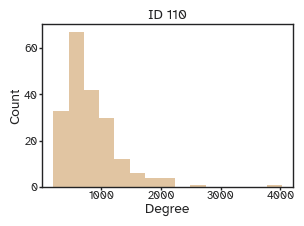

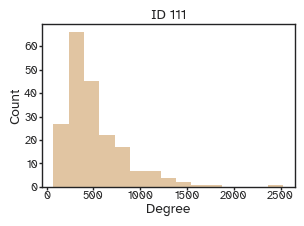

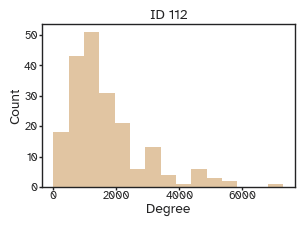

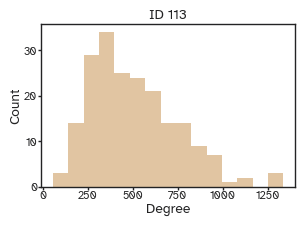

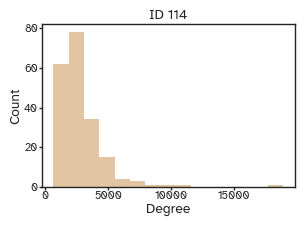

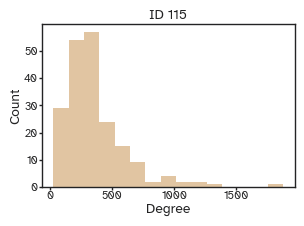

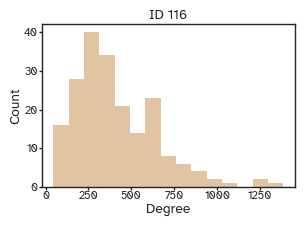

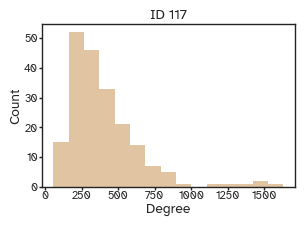

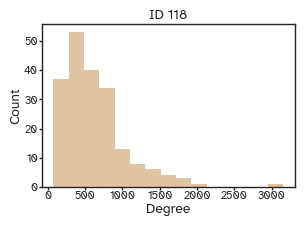

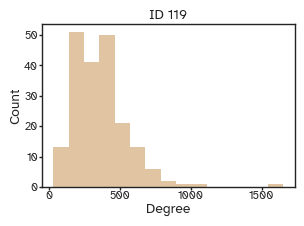

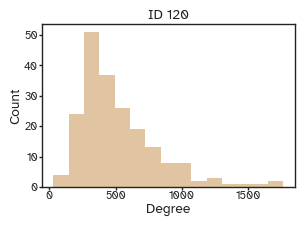

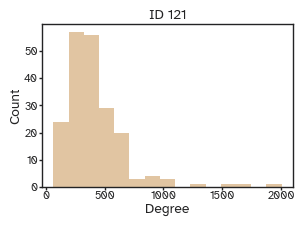

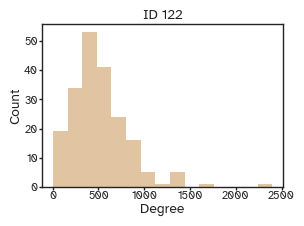

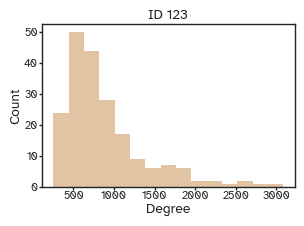

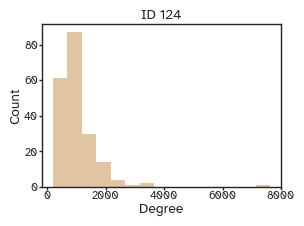

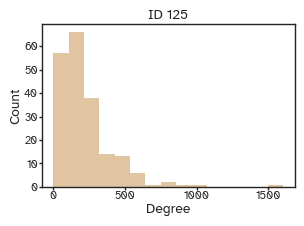

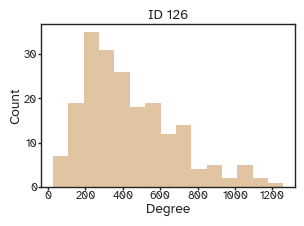

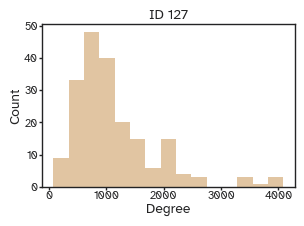

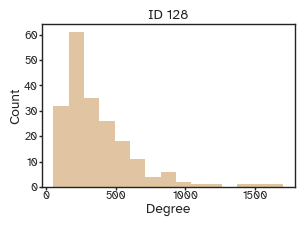

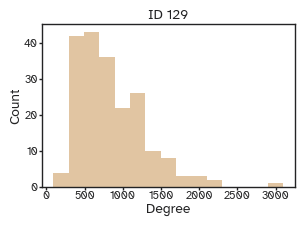

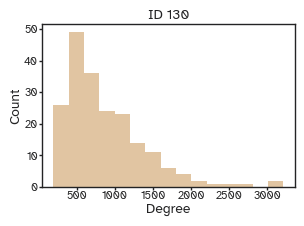

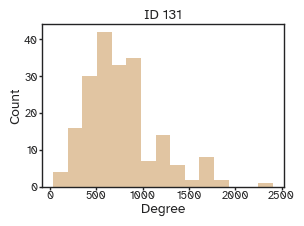

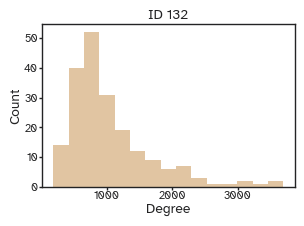

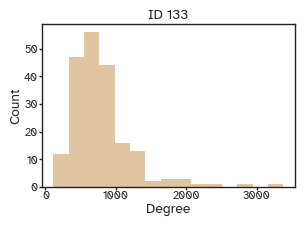

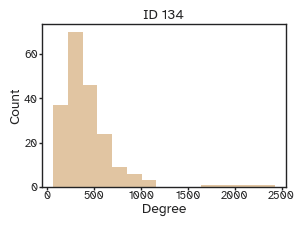

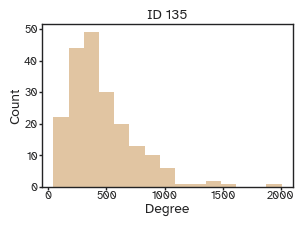

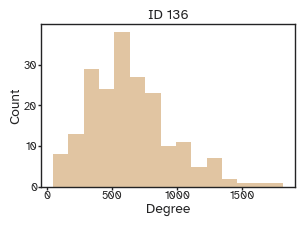

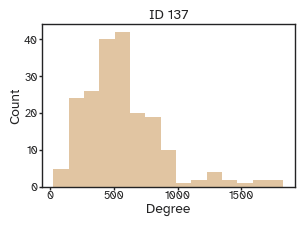

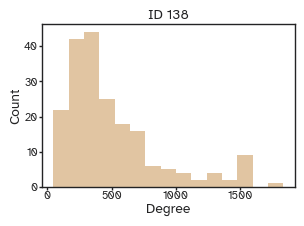

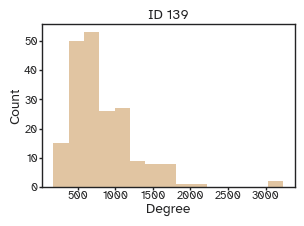

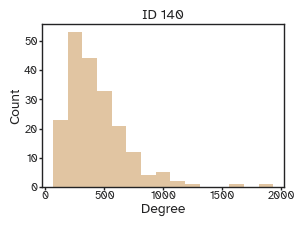

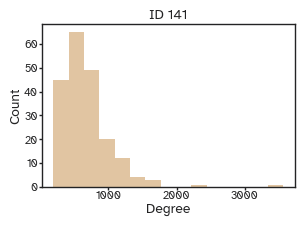

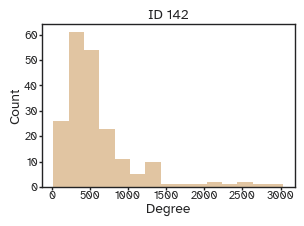

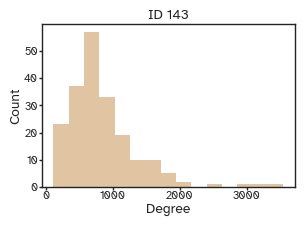

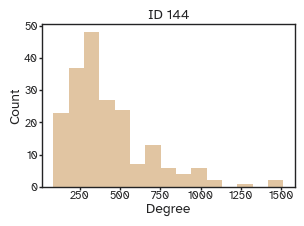

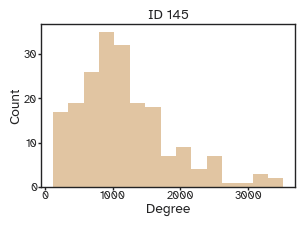

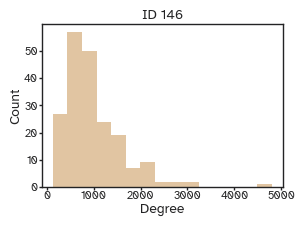

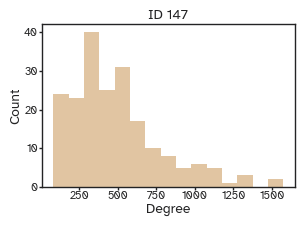

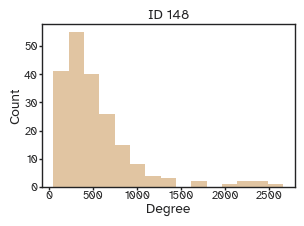

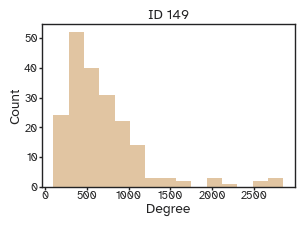

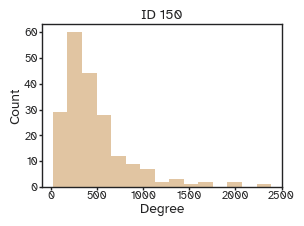

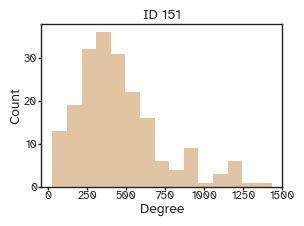

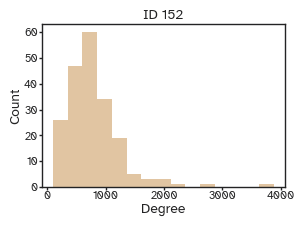

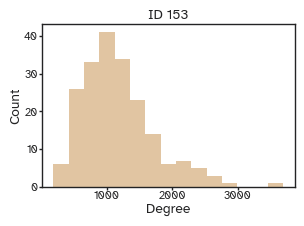

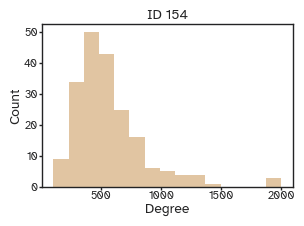

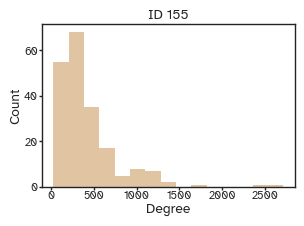

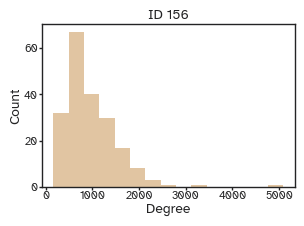

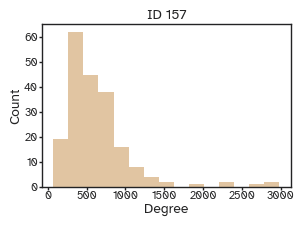

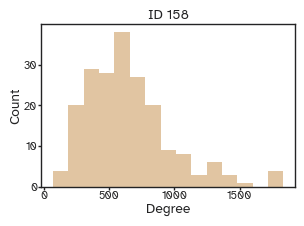

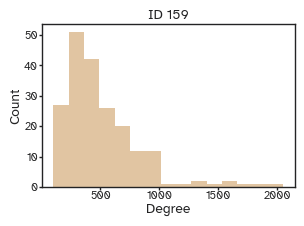

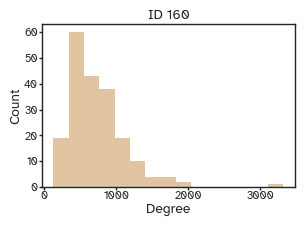

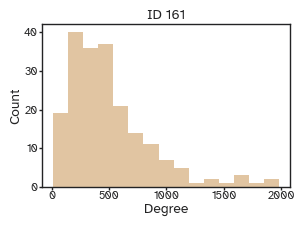

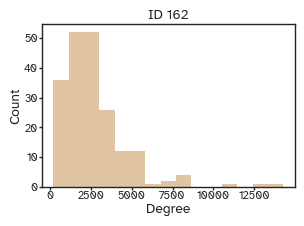

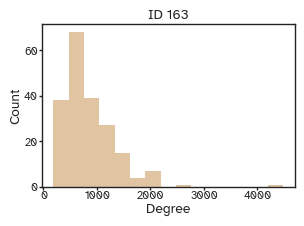

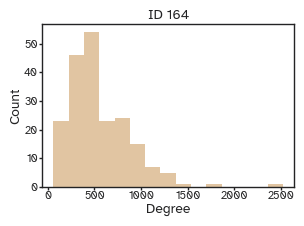

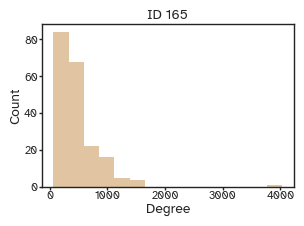

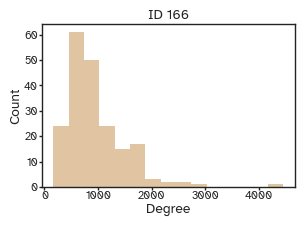

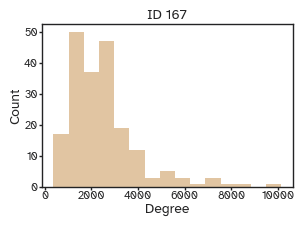

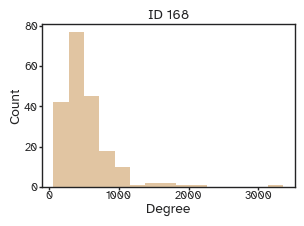

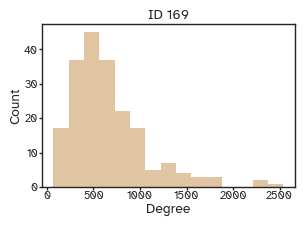

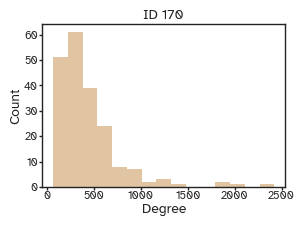

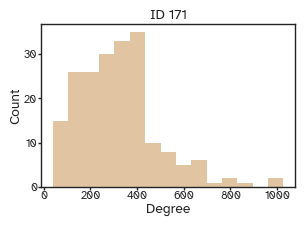

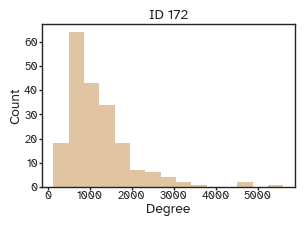

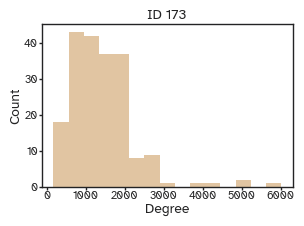

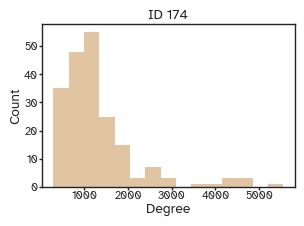

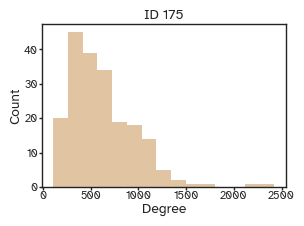

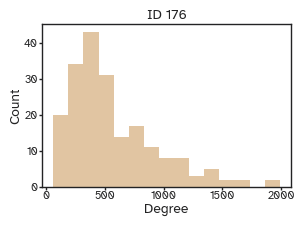

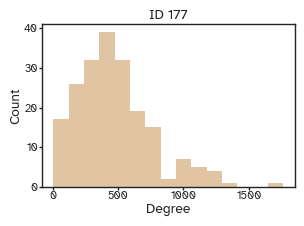

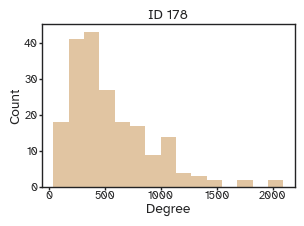

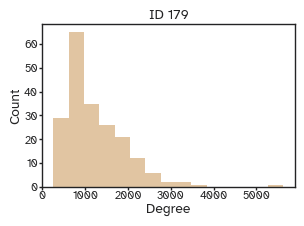

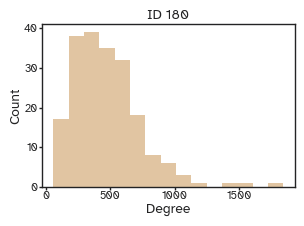

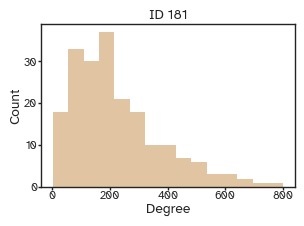

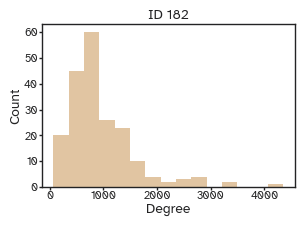

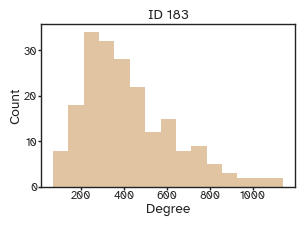

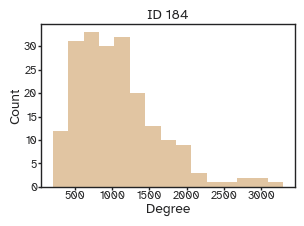

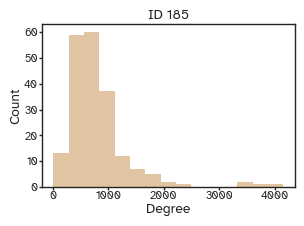

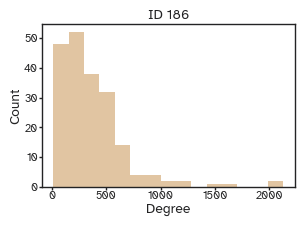

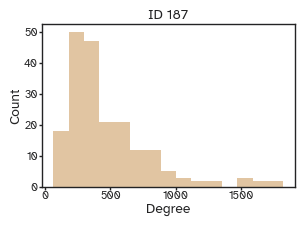

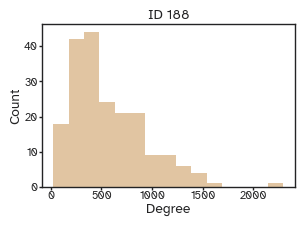

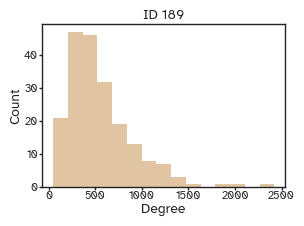

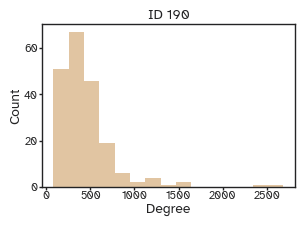

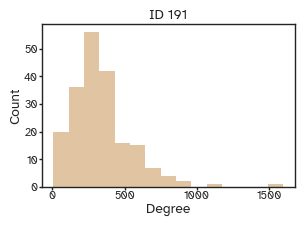

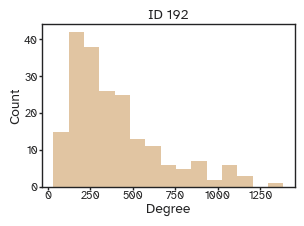

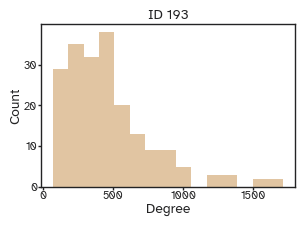

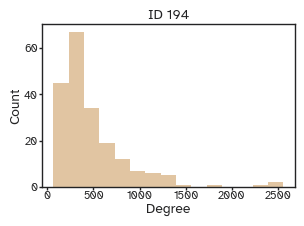

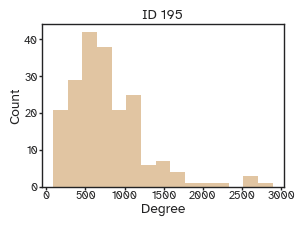

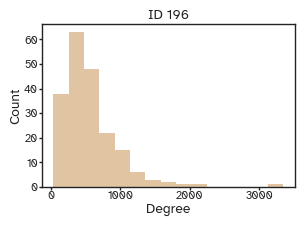

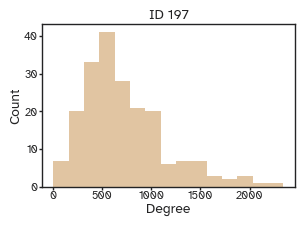

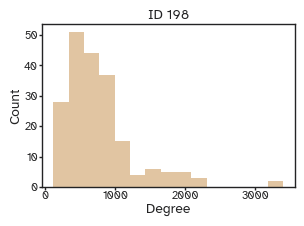

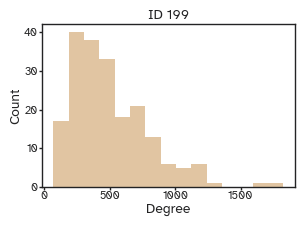

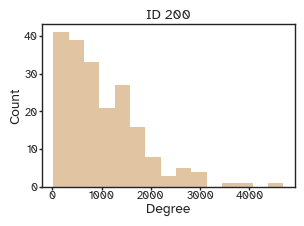

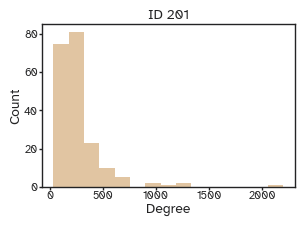

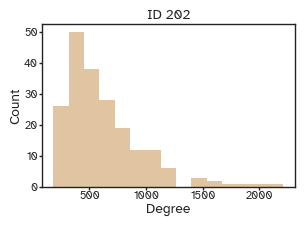

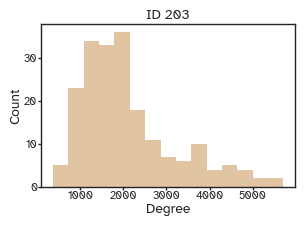

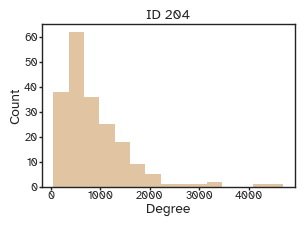

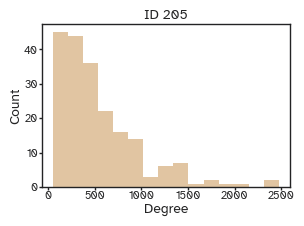

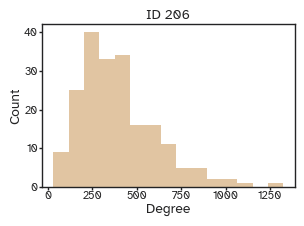

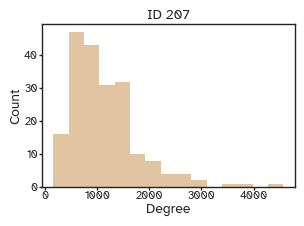

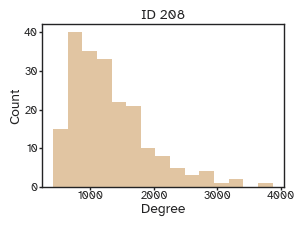

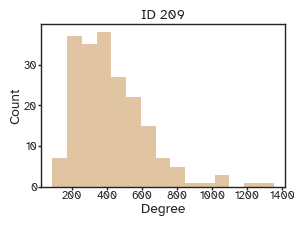

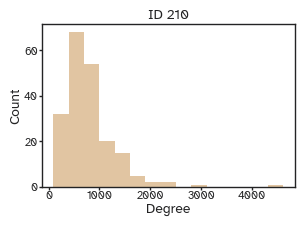

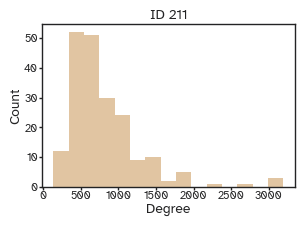

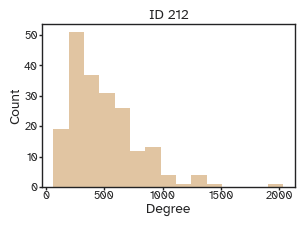

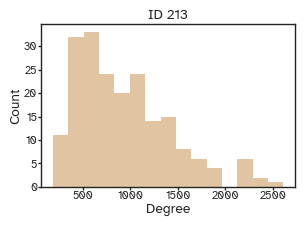

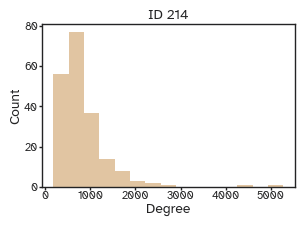

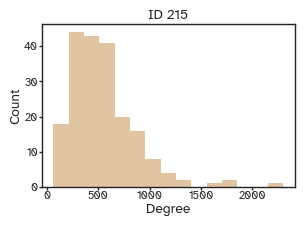

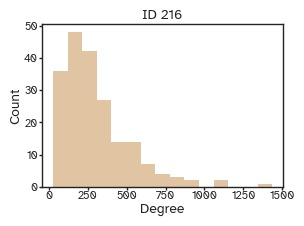

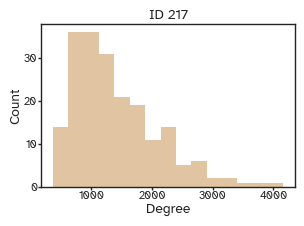

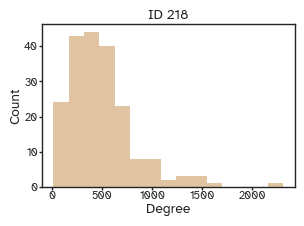

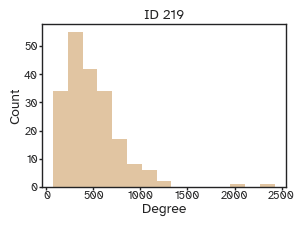

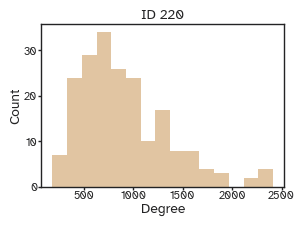

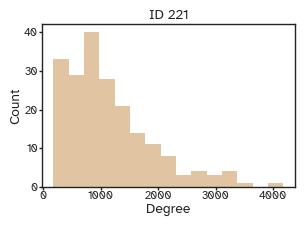

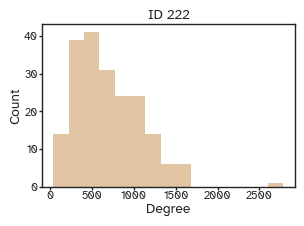

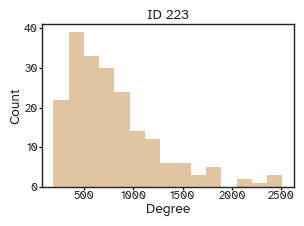

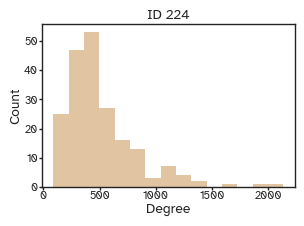

In [9]:
from src.analysis.metric_calculators import StaticMetricCalculator

save_path_degree_hists = save_path / "degree_hists"
save_path_degree_hists.mkdir(parents=True, exist_ok=True)

print(save_path_degree_hists)

densities = []
for id, conn in enumerate(connectomes): 
    metric_calculator = StaticMetricCalculator(conn, distance_matrix=None)  
    density = metric_calculator.calculate_metric("density") 
    densities.append(density)
    
    fig = plt.figure(figsize=(viz.cm_to_inch((8,6))))
    plt.hist(conn.sum(axis=0), bins=15, color="#E1C5A2")
    plt.xlabel("Degree")
    plt.ylabel("Count") 
    plt.title(f"ID {id}")
    plt.tight_layout()
    plt.savefig(save_path_degree_hists / f"density_hist_connectome_15_bins_{id}.pdf")


print(densities)
plt.show()

# General things

In [5]:

# # Set style
# sns.set_style("whitegrid")
# plt.rcParams['figure.facecolor'] = 'white'
# plt.rcParams['axes.facecolor'] = 'white'

# Load the data
df = pd.read_csv('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/connectome_quality_summary.csv')

# Create output directory
output_dir = save_path 
# output_dir.mkdir(exist_ok=True)

# Define metrics to plot (excluding IDs and categorical variables)
metrics = [
    'n_disconnected', 'n_components', 'largest_component_pct', 'density',
    'mean_degree', 'cv_degree', 'degree_gini', 'clustering',
    'path_length', 'small_world_sigma', 'global_efficiency', 'transitivity',
    'omega', 'weight_skew', 'modularity', 'n_modules', 'quality_score'
]

# Metric labels for better visualization
metric_labels = {
    'n_disconnected': 'Number of Disconnected Components',
    'n_components': 'Number of Components',
    'largest_component_pct': 'Largest Component (%)',
    'density': 'Network Density',
    'mean_degree': 'Mean Degree',
    'cv_degree': 'CV of Degree',
    'degree_gini': 'Degree Gini Coefficient',
    'clustering': 'Clustering Coefficient',
    'path_length': 'Average Path Length',
    'small_world_sigma': 'Small-World Sigma',
    'global_efficiency': 'Global Efficiency',
    'transitivity': 'Transitivity',
    'omega': 'Small-World Omega',
    'weight_skew': 'Weight Skewness',
    'modularity': 'Modularity',
    'n_modules': 'Number of Modules',
    'quality_score': 'Quality Score'
}


def plot_metric_histogram(data, metric, save_path):
    """
    Plot histogram for a single metric with similar layout to reference code.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame containing the metric data
    metric : str
        Name of the metric column to plot
    save_path : Path or str
        Path to save the figure
    """
    fig, ax = plt.subplots(figsize=(viz.cm_to_inch((10, 6)))) # 10, 6))
    
    # Get the data
    values = data[metric].dropna()
    
    # Create histogram
    n, bins, patches = ax.hist(values, bins=30) # , color='steelblue', 
                                # alpha=0.7,
                                # edgecolor='black', linewidth=0.5)
    
    ax.set_xlim(left=values.min(), right=values.max() * 1.2)
    
    # Add statistics text box
    mean_val = values.mean()
    median_val = values.median()
    std_val = values.std()
    
    stats_text = f'n = {len(values)}\n'
    stats_text += f'Mean = {mean_val:.3f}\n'
    stats_text += f'Median = {median_val:.3f}\n'
    stats_text += f'SD = {std_val:.3f}'

    # Add a few cm to the right
    fig.subplots_adjust(right=0.85)
    
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right') 
            # bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            # fontsize=10, family='monospace')
    
    # Labels and title
    ax.set_xlabel(metric_labels.get(metric, metric)) # , fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency') # , fontsize=12, fontweight='bold')
    ax.set_title(f'Distribution of {metric_labels.get(metric, metric)}') # , fontsize=14, fontweight='bold', pad=20)

    # Grid
    # ax.grid(True, alpha=0.3, linestyle='--')
    # ax.set_axisbelow(True)
    
    # Tight layout
    plt.tight_layout()
    
    # Save
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

    print(f"Saved: {save_path}")


# Generate histograms for all metrics
print("Generating metric histograms...")
for metric in metrics:
    if metric in df.columns:
        plot_metric_histogram(df, metric, output_dir / f'{metric}_histogram.pdf')

print(f"\nAll histograms saved to: {output_dir}")

# ============================================================================
# PART 2: Identify connectomes with not exactly one disconnected component
# ============================================================================


# Assuming you have eta and gamma columns in a separate file or they need to be loaded
# For now, filtering by n_disconnected != 1
anomalous = df[df['n_disconnected'] != 1].copy()

if len(anomalous) > 0:
    print(f"\nFound {len(anomalous)} connectomes with n_disconnected != 1:\n")
    
    # Display relevant columns
    display_cols = ['connectome_id', 'n_disconnected', 'n_components', 
                    'largest_component_pct', 'quality_score']
    
    # Add eta and gamma if they exist
    if 'eta' in df.columns:
        display_cols.insert(1, 'eta')
    if 'gamma' in df.columns:
        display_cols.insert(2, 'gamma')
    
    print(anomalous[display_cols].to_string(index=False))
    
    # Save to CSV
    anomalous_path = output_dir / 'anomalous_connectomes.csv'
    anomalous.to_csv(anomalous_path, index=False)
    print(f"\nAnomaly details saved to: {anomalous_path}")
else:
    print("\nAll connectomes have exactly one disconnected component (n_disconnected = 1)")

# ============================================================================
# PART 3: Plot degree distributions for all connectomes
# ============================================================================

def plot_all_degree_distributions(connectomes, save_path, cols=5):
    """
    Plot degree distributions for all connectomes in a large grid.
    
    Parameters:
    -----------
    connectomes : numpy.ndarray
        Array of shape (n_connectomes, n_nodes, n_nodes)
    save_path : Path or str
        Path to save the figure
    cols : int
        Number of columns in the grid
    """
    n_connectomes = connectomes.shape[0]
    rows = int(np.ceil(n_connectomes / cols))
    
    # Create large figure
    fig, axes = plt.subplots(rows, cols, figsize=(viz.cm_to_inch((18, 150))), sharex=True, sharey=True) # cols*2.5, rows*2))
    axes = axes.flatten()
    
    print(f"\nGenerating degree distribution plots for {n_connectomes} connectomes...")
    
    for idx in range(n_connectomes):
        ax = axes[idx]
        
        # Calculate degree distribution (sum along axis for adjacency matrix)
        degree = connectomes[idx].sum(axis=1)
        
        # Plot histogram
        ax.hist(degree, bins=20) # , # color='steelblue', alpha=0.7, 
                # edgecolor='black', linewidth=0.5)
        
        # Title with connectome ID 
        ax.set_title(f'ID: {idx}') # , fontsize=8, fontweight='bold')
        
        # Set ylabel only for first column
        if idx % cols == 0:
            ax.set_ylabel('Count') # , fontsize=7)
            
        # Set xlabel only for bottom row
        if idx // cols == rows - 1:
            ax.set_xlabel('Degree') # , fontsize=7)
        # ax.set_ylabel('Count') # , fontsize=7)
        # ax.tick_params()# labelsize=6)
        # ax.grid(True, alpha=0.3, linestyle='--')
        
        # if (idx + 1) % 25 == 0:
        #     print(f"  Processed {idx + 1}/{n_connectomes} connectomes...")
    
    # Hide empty subplots
    for idx in range(n_connectomes, len(axes)):
        axes[idx].axis('off')
    
    # Overall title
    fig.suptitle('Degree Distributions for All Connectomes') # , 
                #  fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout() # rect=[0, 0, 1, 0.99])
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()
    
    print(f"\nDegree distributions saved to: {save_path}")


plot_all_degree_distributions(connectomes, output_dir / 'all_degree_distributions.pdf')



Generating metric histograms...
Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/basic_analyses/01_consensus_bin_density_10_percent_50/n_disconnected_histogram.pdf
Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/basic_analyses/01_consensus_bin_density_10_percent_50/n_components_histogram.pdf
Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/basic_analyses/01_consensus_bin_density_10_percent_50/largest_component_pct_histogram.pdf
Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/basic_analyses/01_consensus_bin_density_10_percent_50/density_histogram.pdf
Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/basic_analyses/01_consensus_bin_density_10_percent_50/mean_degree_histogram.pdf
Saved: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/basic_analyses/01_consensus_bin_density_10_percent_50/cv_deg